In [1]:
import torch
import torch.optim as optim
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
from nflows import flows, transforms, distributions

from src.diffeomorphisms.vector.nflow import NFlowVectorDiffeomorphism
from src.dimension_reduction.principal_geodesic_analysis.vector.l2_tangent_space_pca import l2TangentSpacePCAVectorSolver
from src.manifolds.euclidean.vector.pullback.standard import StandardPullbackVectorEuclidean
from src.manifolds.euclidean.vector.standard import StandardVectorEuclidean
from src.manifolds.isometrized_euclidean.vector import l2IsometrizedVectorEuclidean
from src.multimodal.sum_of_diagonal_gaussian import SumOfDiagonalGaussian
from src.transforms.parity.tanh import TanhParityTransform
from src.transforms.householder_linear import HouseholderLinearTransform

device = "cuda" if torch.cuda.is_available() else "cpu"

# Set random seed for reproducibility
torch.manual_seed(31)

plt.rcParams['font.size'] = 20  # Change this value to your desired font size

### Learning Geometry ###

/Users/wdiepeveen/Documents/Postdoc/projects/2 - Riemannian geometry-based fairness in data science/src/iso-Riemannian-geometry/.venv/lib/python3.13/site-packages/torch/functional.py:505: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /Users/runner/work/pytorch/pytorch/aten/src/ATen/native/TensorShape.cpp:4384.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


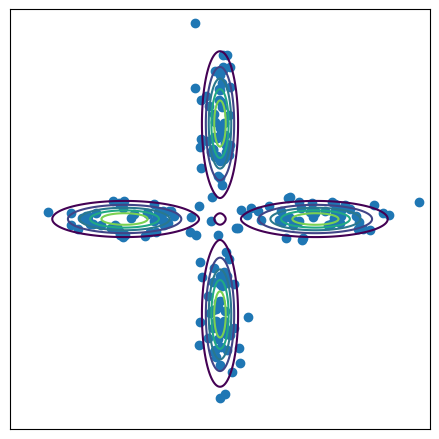

In [2]:
# Construct dataset
def multi_modal_gaussian_sampling(model, num_samples):
    def divide_number(n):
        if n % 4 == 0:
            # If the number is divisible by 4, divide it into four equal parts
            return n // 4, n // 4, n // 4, n // 4
        else:
            # If not divisible by 4, distribute the remainder
            q, r = divmod(n, 4)
            return (q + (r > 0), q + (r > 1), q + (r > 2), q)
        
    A_size, B_size, C_size, D_size = divide_number(num_samples)

    data_A = model.psi[0].offset[None] + 1 / torch.sqrt(model.psi[0].inverse_diagonal)[None] * torch.randn(A_size, 2)
    data_B = model.psi[1].offset[None] + 1 / torch.sqrt(model.psi[1].inverse_diagonal)[None] * torch.randn(B_size, 2)

    data_C = model.psi[2].offset[None] + 1 / torch.sqrt(model.psi[2].inverse_diagonal)[None] * torch.randn(C_size, 2)
    data_D = model.psi[3].offset[None] + 1 / torch.sqrt(model.psi[3].inverse_diagonal)[None] * torch.randn(D_size, 2)

    data = torch.cat([data_A, data_B, data_C, data_D], 0)

    # Generate random permutation of indices
    perm = torch.randperm(num_samples)

    # Shuffle the data tensor along the 0th axis
    return data[perm]

num_samples = 200
offset, a1, a2, w1, w2, w3, w4 = 5., 1/4, 4, 1, 1, 1, 1
quadruple_gaussian = SumOfDiagonalGaussian(torch.tensor([[a1, a2], [a2, a1], [a1, a2], [a2, a1]]), 
                                           torch.tensor([[0., -offset], [offset, 0.], [0., offset], [-offset, 0.]]), 
                                           torch.tensor([w1, w2, w3, w4]))

data_train = multi_modal_gaussian_sampling(quadruple_gaussian, num_samples)
mean = data_train.mean(0)
data_train -= mean[None]
norm = data_train.norm(2,1).max()
data_train /= norm

train_loader = DataLoader(data_train, batch_size=16, shuffle=False)

# plot data
offset = 5

xx = torch.linspace(-6.0 - offset, 6.0 + offset, 500)
yy = torch.linspace(-6.0 - offset, 6.0 + offset, 500)
x_grid, y_grid = torch.meshgrid(xx, yy)

xy_grid = torch.zeros((*x_grid.shape,2))
xy_grid[:,:,0] = x_grid
xy_grid[:,:,1] = y_grid

density = torch.exp(quadruple_gaussian.log_density(xy_grid.reshape(-1,2)).reshape(x_grid.shape))
levels = torch.linspace(density.min(), density.max(), 7)  # Adjust the number of levels as needed        # Retrieve the automatically generated levels
new_levels = levels[1:]    

plt.contour((x_grid - mean[0])/norm, (y_grid - mean[1])/norm, density, levels=new_levels)
plt.scatter(data_train[:,0], data_train[:,1])
plt.xticks([])  # Remove x-axis ticks
plt.yticks([])  # Remove y-axis ticks
plt.gca().set_aspect('equal', adjustable='box')  # Ensure axes are equally spaced
plt.tight_layout()
plt.show()

In [3]:
# Define the normalizing flow model
def create_flow_model(dim, n_flows, n_hoho, order):
    base_dist = distributions.StandardNormal(shape=[dim])
    transforms_list = []
    for i in range(n_flows):
        transforms_list.append(transforms.normalization.ActNorm(features=dim))
        for k in range(n_hoho):
            transforms_list.append(HouseholderLinearTransform(dim))
        transforms_list.append(TanhParityTransform(dim, order, parity=i%2))
    flow_transforms = transforms.CompositeTransform(transforms_list)
    return flows.Flow(transform=flow_transforms, distribution=base_dist)

In [4]:
# Initialize the model
dim = 2
n_flows = 2
n_hoho = 2
order = 2
model = create_flow_model(dim, n_flows, n_hoho, order).to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=0.2)

In [5]:
# Training loop
def train(model, train_loader, optimizer, n_epochs):
    for epoch in range(n_epochs):
        for batch_idx, x in enumerate(train_loader):
            optimizer.zero_grad()
            
            # Compute loss
            loss = -model.log_prob(x).mean()
            
            # Backward pass and optimization
            loss.backward()
            optimizer.step()
            
        print(f"Epoch {epoch+1}/{n_epochs}, Loss: {loss.item():.4f}")

In [6]:
# Train the model
n_epochs = 500
train(model, train_loader, optimizer, n_epochs)

Epoch 1/500, Loss: 0.5101
Epoch 2/500, Loss: 0.5068
Epoch 3/500, Loss: 0.5066
Epoch 4/500, Loss: 0.5086
Epoch 5/500, Loss: 0.5118
Epoch 6/500, Loss: 0.5157
Epoch 7/500, Loss: 0.5198
Epoch 8/500, Loss: 0.5236
Epoch 9/500, Loss: 0.5272
Epoch 10/500, Loss: 0.5303
Epoch 11/500, Loss: 0.5329
Epoch 12/500, Loss: 0.5352
Epoch 13/500, Loss: 0.5370
Epoch 14/500, Loss: 0.5384
Epoch 15/500, Loss: 0.5394
Epoch 16/500, Loss: 0.5401
Epoch 17/500, Loss: 0.5405
Epoch 18/500, Loss: 0.5407
Epoch 19/500, Loss: 0.5406
Epoch 20/500, Loss: 0.5404
Epoch 21/500, Loss: 0.5401
Epoch 22/500, Loss: 0.5398
Epoch 23/500, Loss: 0.5393
Epoch 24/500, Loss: 0.5389
Epoch 25/500, Loss: 0.5385
Epoch 26/500, Loss: 0.5382
Epoch 27/500, Loss: 0.5378
Epoch 28/500, Loss: 0.5375
Epoch 29/500, Loss: 0.5372
Epoch 30/500, Loss: 0.5370
Epoch 31/500, Loss: 0.5368
Epoch 32/500, Loss: 0.5366
Epoch 33/500, Loss: 0.5364
Epoch 34/500, Loss: 0.5362
Epoch 35/500, Loss: 0.5360
Epoch 36/500, Loss: 0.5358
Epoch 37/500, Loss: 0.5356
Epoch 38/5

In [7]:
# Generate samples
@torch.no_grad()
def generate_samples(model, n_samples):
    samples = model.sample(n_samples).cpu()
    return samples

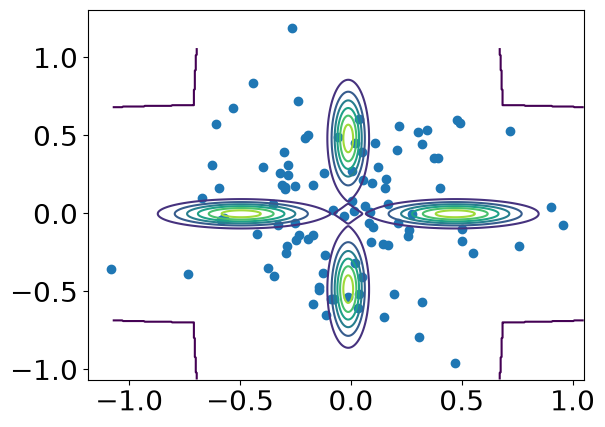

In [8]:
# Visualize generated samples
samples = generate_samples(model, 100)

plt.contour((x_grid - mean[0])/norm, (y_grid - mean[1])/norm, density)
plt.scatter(samples[:,0], samples[:,1])
plt.show()

In [9]:
# Construct diffeomorphism
phi = NFlowVectorDiffeomorphism(2, model)

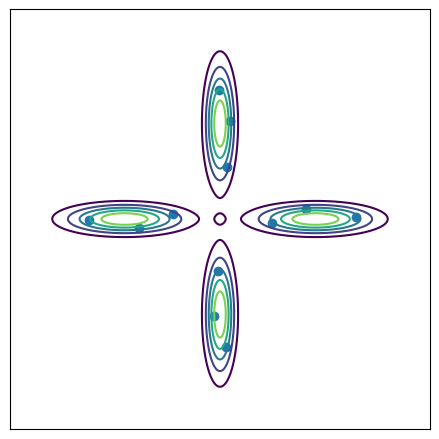

In [10]:
# special points
x0 = (torch.tensor([0.3,-1.7- offset]) - mean)/norm
x1 = (torch.tensor([-0.3,-0.1 - offset]) - mean)/norm
x2 = (torch.tensor([-0.1,2.3 - offset]) - mean)/norm

y0 = (torch.tensor([-2.3+ offset,-0.2]) - mean)/norm
y1 = (torch.tensor([-0.5 + offset,0.5]) - mean)/norm
y2 = (torch.tensor([2.1 + offset,0.1]) - mean)/norm

u0 = -x0
u1 = -x1
u2 = -x2

v0 = -y0
v1 = -y1
v2 = -y2

data = torch.cat([x0[None], x1[None], x2[None], y0[None], y1[None], y2[None], u0[None], u1[None], u2[None], v0[None], v1[None], v2[None]],0)

plt.contour((x_grid - mean[0])/norm, (y_grid - mean[1])/norm, density, levels=new_levels)
plt.scatter(data[:,0], data[:,1])
plt.xticks([])  # Remove x-axis ticks
plt.yticks([])  # Remove y-axis ticks
plt.gca().set_aspect('equal', adjustable='box')  # Ensure axes are equally spaced
plt.tight_layout()
plt.savefig("results/quadruple_gaussian/additive-tanh-isotropic-nflow-pullback/data.eps")
plt.show()

### Naive Riemannian data analysis ###

In [11]:
# Construct pullback manifold
manifold = StandardPullbackVectorEuclidean(phi)

In [12]:
# compute geodesic
t = torch.linspace(0.,1.,20)

geodesic = manifold.geodesic(x0[None,None],y2[None,None],t).detach()[0,0,0]

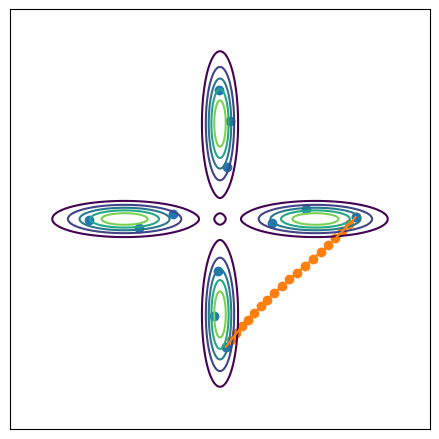

In [13]:
# plot geodesics
plt.contour((x_grid - mean[0])/norm, (y_grid - mean[1])/norm, density, levels=new_levels)
plt.plot(geodesic[:,0], geodesic[:,1], color=plt.rcParams['axes.prop_cycle'].by_key()['color'][1])
plt.scatter(geodesic[:,0], geodesic[:,1],  color=plt.rcParams['axes.prop_cycle'].by_key()['color'][1])
plt.scatter(data[:,0], data[:,1], color=plt.rcParams['axes.prop_cycle'].by_key()['color'][0])
plt.xticks([])  # Remove x-axis ticks
plt.yticks([])  # Remove y-axis ticks
plt.gca().set_aspect('equal', adjustable='box')  # Ensure axes are equally spaced
plt.tight_layout()
plt.savefig("results/quadruple_gaussian/additive-tanh-isotropic-nflow-pullback/geodesic.eps")
plt.show()

In [14]:
# compute barycentre
bary = manifold.barycentre(data.to(device)).detach().cpu()

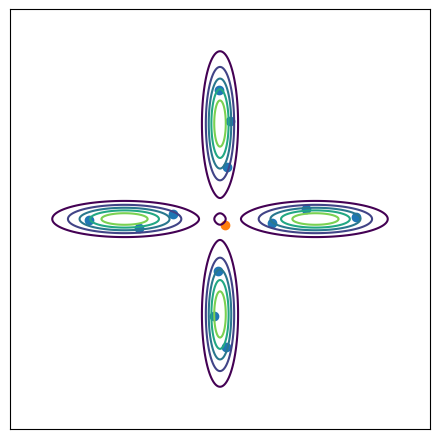

In [15]:
# plot barycentres
plt.contour((x_grid - mean[0])/norm, (y_grid - mean[1])/norm, density, levels=new_levels)
plt.scatter(data[:,0], data[:,1])
plt.scatter(bary[0], bary[1])
plt.xticks([])  # Remove x-axis ticks
plt.yticks([])  # Remove y-axis ticks
plt.gca().set_aspect('equal', adjustable='box')  # Ensure axes are equally spaced
plt.tight_layout()
plt.savefig("results/quadruple_gaussian/additive-tanh-isotropic-nflow-pullback/barycentre.eps")
plt.show()

In [16]:
# construct l2-pga solver
l2_pga_solver_bary = l2TangentSpacePCAVectorSolver(data.to(device), manifold, bary.to(device))

In [17]:
# compute low rank approximations
Xi_bary, exp_bary_Xi, _ = l2_pga_solver_bary.solve(1) # compute rank 1 approximation

Computing rank 1 approximation on tangent space
Computing rank 1 approximation on euclidean space
Computing rank 1 errors for data point 1/12
Computing rank 1 errors for data point 2/12
Computing rank 1 errors for data point 3/12
Computing rank 1 errors for data point 4/12
Computing rank 1 errors for data point 5/12
Computing rank 1 errors for data point 6/12
Computing rank 1 errors for data point 7/12
Computing rank 1 errors for data point 8/12
Computing rank 1 errors for data point 9/12
Computing rank 1 errors for data point 10/12
Computing rank 1 errors for data point 11/12
Computing rank 1 errors for data point 12/12
Computing rank 1 errors


In [18]:
# compute learned manifold
log_bary_endpoints = torch.stack([1.4 * Xi_bary[-1], 1.7 * Xi_bary[0]],dim=0)
end_points = manifold.exp(bary[None], log_bary_endpoints[None])[0]
mfld_fit = manifold.geodesic(end_points[0][None,None], end_points[1][None,None], t).detach().cpu()[0,0,0]

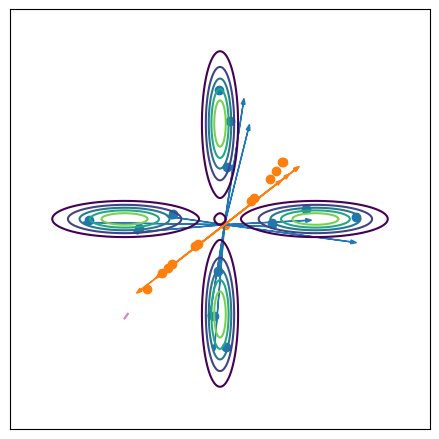

In [19]:
# plot tangent space approximations
plt.contour((x_grid - mean[0])/norm, (y_grid - mean[1])/norm, density, levels=new_levels)
plt.scatter(data[:,0], data[:,1])
plt.scatter(bary[0], bary[1])
for i in range(l2_pga_solver_bary.log_x_data.shape[0]):
    plt.arrow(bary[0], bary[1], l2_pga_solver_bary.log_x_data[i, 0], l2_pga_solver_bary.log_x_data[i, 1], head_width=0.2/norm, color=plt.rcParams['axes.prop_cycle'].by_key()['color'][0])
for i in range(l2_pga_solver_bary.log_x_data.shape[0]):
    plt.arrow(bary[0], bary[1], Xi_bary[i, 0], Xi_bary[i, 1], head_width=0.2/norm, color=plt.rcParams['axes.prop_cycle'].by_key()['color'][1])
plt.scatter(exp_bary_Xi[:,0], exp_bary_Xi[:,1], color=plt.rcParams['axes.prop_cycle'].by_key()['color'][1])
plt.plot(mfld_fit[:,0], mfld_fit[:,1], color=plt.rcParams['axes.prop_cycle'].by_key()['color'][6], linestyle='--')
plt.xticks([])  # Remove x-axis ticks
plt.yticks([])  # Remove y-axis ticks
plt.gca().set_aspect('equal', adjustable='box')  # Ensure axes are equally spaced
plt.tight_layout()
plt.savefig("results/quadruple_gaussian/additive-tanh-isotropic-nflow-pullback/l2-pga.eps")
plt.show()


In [20]:
print(((data - exp_bary_Xi)**2).mean(0).sum().sqrt() / ((data - bary)**2).mean(0).sum().sqrt())

tensor(0.6935)


In [21]:
# compute \|M-I\|
Xi = l2_pga_solver_bary.log_x_data.detach().clone().requires_grad_(True)  # (n, 2)

# If your exp expects batched basepoints and tangent vectors:
Y = manifold.exp(bary[None], Xi[None]).squeeze(0)   # (n, 2)

n, d = Xi.shape
M = torch.empty(n, d, d, device=Xi.device, dtype=Xi.dtype)
I = torch.eye(d, device=Xi.device, dtype=Xi.dtype)

for i in range(n):
    cols = []
    for k in range(d):
        grad_outputs = torch.zeros_like(Y)
        grad_outputs[i, k] = 1.0
        g = torch.autograd.grad(
            Y,
            Xi,
            grad_outputs=grad_outputs,
            retain_graph=True,
            create_graph=False,
        )[0]
        cols.append(g[i])

    J = torch.stack(cols, dim=0)   # (2, 2)
    M[i] = J.T @ J

# compute and print mean and std of ||M-I|| for all data points
isometry_norms = torch.norm(M - I, p='fro', dim=(1,2))
isometry_rel_rmse = torch.sqrt(torch.mean(isometry_norms ** 2) / 2).item()

print(f"Isometry relative RMSE: {isometry_rel_rmse}")

Isometry relative RMSE: 0.21857492625713348


### Isometrized Riemannian data analysis ###

In [22]:
num_intervals = 100
iso_manifold = l2IsometrizedVectorEuclidean(manifold, num_intervals=num_intervals)

In [23]:
# compute geodesic
t = torch.linspace(0.,1.,20)

iso_geodesic = iso_manifold.geodesic(x0[None,None],y2[None,None],t).detach()[0,0,0]

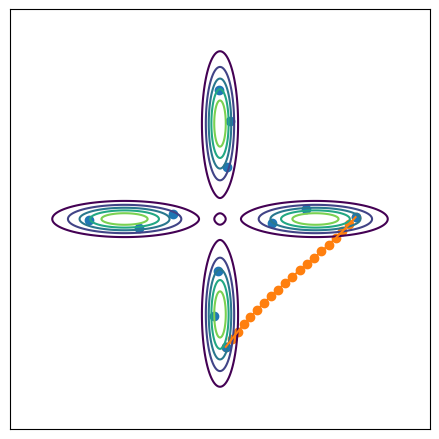

In [24]:
# plot geodesic
plt.contour((x_grid - mean[0])/norm, (y_grid - mean[1])/norm, density, levels=new_levels)
plt.plot(iso_geodesic[:,0], iso_geodesic[:,1], color=plt.rcParams['axes.prop_cycle'].by_key()['color'][1])
plt.scatter(iso_geodesic[:,0], iso_geodesic[:,1],  color=plt.rcParams['axes.prop_cycle'].by_key()['color'][1])
plt.scatter(data[:,0], data[:,1], color=plt.rcParams['axes.prop_cycle'].by_key()['color'][0])
plt.xticks([])  # Remove x-axis ticks
plt.yticks([])  # Remove y-axis ticks
plt.gca().set_aspect('equal', adjustable='box')  # Ensure axes are equally spaced
plt.tight_layout()
plt.savefig("results/quadruple_gaussian/additive-tanh-isotropic-nflow-pullback/iso-geodesic.eps")
plt.show()

In [25]:
# construct l2-pga solver
iso_l2_pga_solver_bary = l2TangentSpacePCAVectorSolver(data, iso_manifold, bary)

In [26]:
# compute low rank approximations
iso_Xi_bary, iso_exp_bary_Xi, _ = iso_l2_pga_solver_bary.solve(1) # compute rank 1 approximation

Computing rank 1 approximation on tangent space
Computing rank 1 approximation on euclidean space
Computing rank 1 errors for data point 1/12
Computing rank 1 errors for data point 2/12
Computing rank 1 errors for data point 3/12
Computing rank 1 errors for data point 4/12
Computing rank 1 errors for data point 5/12
Computing rank 1 errors for data point 6/12
Computing rank 1 errors for data point 7/12
Computing rank 1 errors for data point 8/12
Computing rank 1 errors for data point 9/12
Computing rank 1 errors for data point 10/12
Computing rank 1 errors for data point 11/12
Computing rank 1 errors for data point 12/12
Computing rank 1 errors


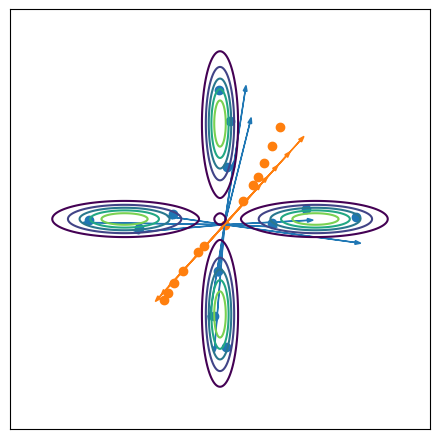

In [28]:
# plot tangent space approximations
plt.contour((x_grid - mean[0])/norm, (y_grid - mean[1])/norm, density, levels=new_levels)
plt.scatter(data[:,0], data[:,1])
plt.scatter(bary[0], bary[1])
for i in range(iso_l2_pga_solver_bary.log_x_data.shape[0]):
    plt.arrow(bary[0], bary[1], iso_l2_pga_solver_bary.log_x_data[i, 0], iso_l2_pga_solver_bary.log_x_data[i, 1], head_width=0.2/norm, color=plt.rcParams['axes.prop_cycle'].by_key()['color'][0])
for i in range(iso_l2_pga_solver_bary.log_x_data.shape[0]):
    plt.arrow(bary[0], bary[1], iso_Xi_bary[i, 0], iso_Xi_bary[i, 1], head_width=0.2/norm, color=plt.rcParams['axes.prop_cycle'].by_key()['color'][1])
plt.scatter(iso_exp_bary_Xi[:,0], iso_exp_bary_Xi[:,1], color=plt.rcParams['axes.prop_cycle'].by_key()['color'][1])
# plt.plot(iso_mfld_fit[:,0], iso_mfld_fit[:,1], color=plt.rcParams['axes.prop_cycle'].by_key()['color'][6], linestyle='--')
plt.xticks([])  # Remove x-axis ticks
plt.yticks([])  # Remove y-axis ticks
plt.gca().set_aspect('equal', adjustable='box')  # Ensure axes are equally spaced
plt.tight_layout()
plt.savefig("results/quadruple_gaussian/additive-tanh-isotropic-nflow-pullback/iso-l2-pga.eps")
plt.show()

In [29]:
print(((data - iso_exp_bary_Xi)**2).mean(0).sum().sqrt() / ((data - bary)**2).mean(0).sum().sqrt())

tensor(0.6735)


In [30]:
# compute \|M-I\|
Xi = iso_l2_pga_solver_bary.log_x_data.detach().clone().requires_grad_(True)  # (n, 2)

# If your exp expects batched basepoints and tangent vectors:
Y = iso_manifold.exp(bary[None], Xi[None], no_grad=False).squeeze(0)   # (n, 2)

n, d = Xi.shape
M = torch.empty(n, d, d, device=Xi.device, dtype=Xi.dtype)
I = torch.eye(d, device=Xi.device, dtype=Xi.dtype)

for i in range(n):
    cols = []
    for k in range(d):
        grad_outputs = torch.zeros_like(Y)
        grad_outputs[i, k] = 1.0
        g = torch.autograd.grad(
            Y,
            Xi,
            grad_outputs=grad_outputs,
            retain_graph=True,
            create_graph=False,
        )[0]
        cols.append(g[i])

    J = torch.stack(cols, dim=0)   # (2, 2)
    M[i] = J.T @ J

# compute and print mean and std of ||M-I|| for all data points
iso_isometry_norms = torch.norm(M - I, p='fro', dim=(1,2))
isometry_rel_rmse = torch.sqrt(torch.mean(iso_isometry_norms ** 2) / 2).item()

print(f"Isometry relative RMSE: {isometry_rel_rmse}")

Isometry relative RMSE: 0.16093000769615173


### l2 data analysis ###

In [31]:
# Construct manifold
l2_manifold = StandardVectorEuclidean(2)

In [32]:
# compute geodesic
t = torch.linspace(0.,1.,20)

l2_geodesic = l2_manifold.geodesic(x0[None,None],y2[None,None],t).detach()[0,0,0]

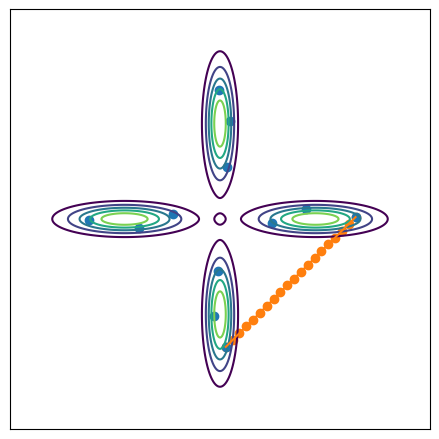

In [33]:
# plot geodesic
plt.contour((x_grid - mean[0])/norm, (y_grid - mean[1])/norm, density, levels=new_levels)
plt.plot(l2_geodesic[:,0], l2_geodesic[:,1], color=plt.rcParams['axes.prop_cycle'].by_key()['color'][1])
plt.scatter(l2_geodesic[:,0], l2_geodesic[:,1],  color=plt.rcParams['axes.prop_cycle'].by_key()['color'][1])
plt.scatter(data[:,0], data[:,1], color=plt.rcParams['axes.prop_cycle'].by_key()['color'][0])
plt.xticks([])  # Remove x-axis ticks
plt.yticks([])  # Remove y-axis ticks
plt.gca().set_aspect('equal', adjustable='box')  # Ensure axes are equally spaced
plt.tight_layout()
plt.savefig("results/quadruple_gaussian/additive-tanh-isotropic-nflow-pullback/l2-geodesic.eps")
plt.show()

In [34]:
# construct l2-pga solver
l2_l2_pga_solver_bary = l2TangentSpacePCAVectorSolver(data, l2_manifold, bary)

In [35]:
# compute low rank approximations
l2_Xi_bary, l2_exp_bary_Xi, _ = l2_l2_pga_solver_bary.solve(1) # compute rank 1 approximation

Computing rank 1 approximation on tangent space
Computing rank 1 approximation on euclidean space
Computing rank 1 errors for data point 1/12
Computing rank 1 errors for data point 2/12
Computing rank 1 errors for data point 3/12
Computing rank 1 errors for data point 4/12
Computing rank 1 errors for data point 5/12
Computing rank 1 errors for data point 6/12
Computing rank 1 errors for data point 7/12
Computing rank 1 errors for data point 8/12
Computing rank 1 errors for data point 9/12
Computing rank 1 errors for data point 10/12
Computing rank 1 errors for data point 11/12
Computing rank 1 errors for data point 12/12
Computing rank 1 errors


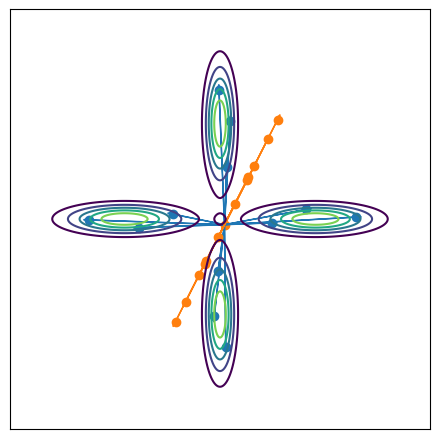

In [45]:
# plot tangent space approximations
plt.contour((x_grid - mean[0])/norm, (y_grid - mean[1])/norm, density, levels=new_levels)
plt.scatter(data[:,0], data[:,1])
plt.scatter(bary[0], bary[1])
for i in range(l2_l2_pga_solver_bary.log_x_data.shape[0]):
    plt.arrow(bary[0], bary[1], l2_l2_pga_solver_bary.log_x_data[i, 0], l2_l2_pga_solver_bary.log_x_data[i, 1], head_width=0.2/norm, color=plt.rcParams['axes.prop_cycle'].by_key()['color'][0])
for i in range(l2_l2_pga_solver_bary.log_x_data.shape[0]):
    plt.arrow(bary[0], bary[1], l2_Xi_bary[i, 0], l2_Xi_bary[i, 1], head_width=0.2/norm, color=plt.rcParams['axes.prop_cycle'].by_key()['color'][1])
plt.scatter(l2_exp_bary_Xi[:,0], l2_exp_bary_Xi[:,1], color=plt.rcParams['axes.prop_cycle'].by_key()['color'][1])
plt.xticks([])  # Remove x-axis ticks
plt.yticks([])  # Remove y-axis ticks
plt.gca().set_aspect('equal', adjustable='box')  # Ensure axes are equally spaced
plt.tight_layout()
plt.savefig("results/quadruple_gaussian/additive-tanh-isotropic-nflow-pullback/l2-l2-pga.eps")
plt.show()

### Comparing naive and isometrized ###

In [37]:
# Compute geodesic relative rmse from the barycentre
squared_geo_errors = torch.zeros(data.shape[0])
dists = ((data - bary)**2).sum(1)
for i, x_i in enumerate(data):
    geodesic_i = manifold.geodesic(bary[None,None], x_i[None,None], t).detach().cpu()[0,0,0]
    iso_geodesic_i = iso_manifold.geodesic(bary[None,None], x_i[None,None], t).detach().cpu()[0,0,0]
    squared_geo_errors[i] = ((geodesic_i - iso_geodesic_i)**2).mean(0).sum()

geo_rel_rmse = (squared_geo_errors.mean() / dists.mean()).sqrt()
print(geo_rel_rmse)

tensor(0.0090)


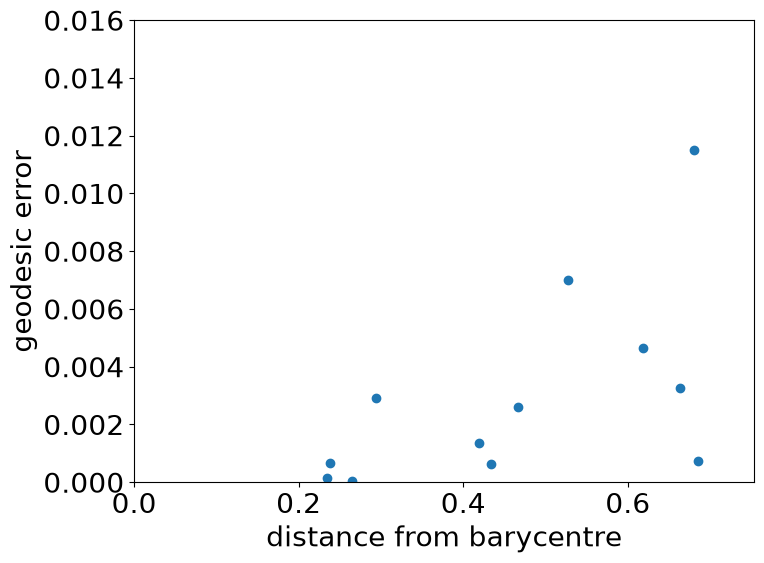

In [38]:
# Make scatter plot
plt.figure(figsize=(8, 6))
plt.scatter(dists.sqrt(), squared_geo_errors.sqrt())
plt.xlim([0.,dists.sqrt().max()*1.1])
plt.ylim([0., 0.016])
plt.xlabel('distance from barycentre')
plt.ylabel('geodesic error')
plt.savefig(f"results/quadruple_gaussian/additive-tanh-isotropic-nflow-pullback/geodesic-error-M{num_intervals}.eps")
plt.show()

In [39]:
# Compute low rank relative rmse from the barycentre
squared_low_rank_errors = ((data - exp_bary_Xi)**2).sum(1)
low_rank_rel_rmse = (squared_low_rank_errors.mean() / dists.mean()).sqrt()

squared_low_rank_iso_errors = ((data - iso_exp_bary_Xi)**2).sum(1)
iso_low_rank_rel_rmse = (squared_low_rank_iso_errors.mean() / dists.mean()).sqrt()

squared_low_rank_l2_errors = ((data - l2_exp_bary_Xi)**2).sum(1)
l2_low_rank_rel_rmse = (squared_low_rank_l2_errors.mean() / dists.mean()).sqrt()

print(low_rank_rel_rmse)
print(iso_low_rank_rel_rmse)
print(l2_low_rank_rel_rmse)

tensor(0.6935)
tensor(0.6735)
tensor(0.6874)


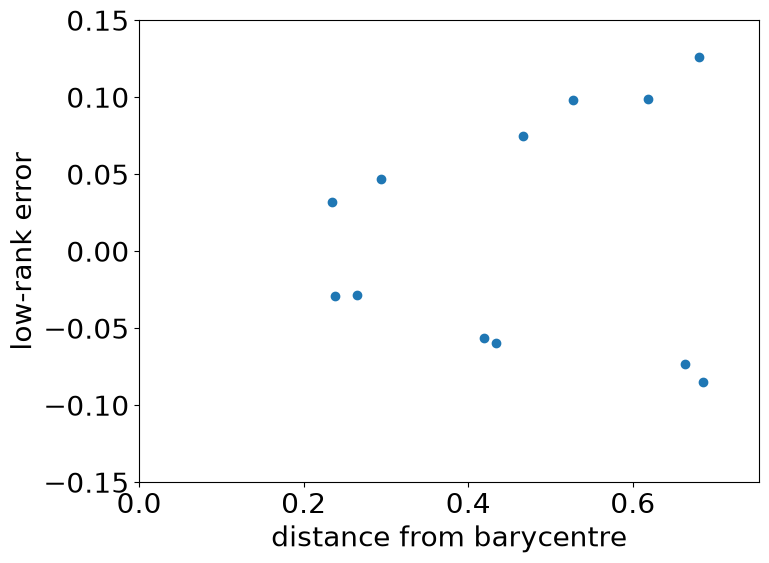

In [40]:
# Make scatter plot
plt.figure(figsize=(8, 6))
plt.scatter(dists.sqrt(), squared_low_rank_errors.sqrt() - squared_low_rank_iso_errors.sqrt())
plt.xlim([0.,dists.sqrt().max()*1.1])
plt.ylim([-0.15, 0.15])
plt.xlabel('distance from barycentre')
plt.ylabel('low-rank error')
plt.savefig(f"results/quadruple_gaussian/additive-tanh-isotropic-nflow-pullback/low-rank-error-M{num_intervals}.eps", bbox_inches='tight')
plt.show()

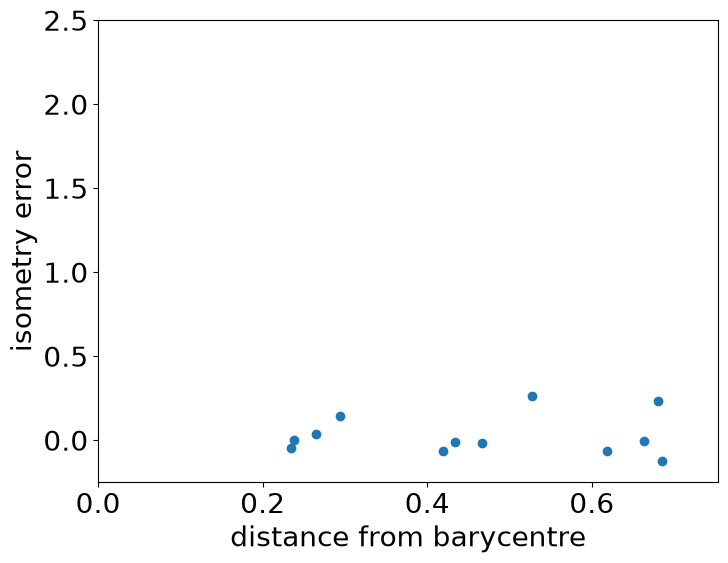

In [41]:
# Make scatter plot
plt.figure(figsize=(8, 6))
plt.scatter(dists.sqrt(), isometry_norms - iso_isometry_norms)
plt.xlim([0.,dists.sqrt().max()*1.1])
plt.ylim([-0.25, 2.5])
plt.xlabel('distance from barycentre')
plt.ylabel('isometry error')
plt.savefig(f"results/quadruple_gaussian/additive-tanh-isotropic-nflow-pullback/isometry-error-M{num_intervals}.eps")
plt.show()

In [42]:
# compare wall time of all manifold mappings for different number of intervals
# with standard pullback geometry as baseline

# %%
import time
import torch
from collections import defaultdict

# %%
# Experiment configuration
N = 64
M = 1
L = 1
K = 8
d = 2  # only used implicitly through manifold.manifold_dimension()

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Number of repetitions for timing
reps = 10
warmup = 3

# %%
def sync_if_needed():
    if device.type == "cuda":
        torch.cuda.synchronize()

def rand_point(shape):
    return torch.randn(*shape, device=device)

def rand_vec(shape):
    return torch.randn(*shape, device=device)

# %%
def benchmark_call(method_call, reps=reps, warmup=warmup):
    for _ in range(warmup):
        _ = method_call()
    sync_if_needed()

    times = []
    for _ in range(reps):
        sync_if_needed()
        start = time.perf_counter()
        _ = method_call()
        sync_if_needed()
        end = time.perf_counter()
        times.append(end - start)

    times_t = torch.tensor(times, dtype=torch.float64)
    return {
        "mean_time": times_t.mean().item(),
        "std_time": times_t.std(unbiased=False).item(),
        "times": times,
    }

# %%
def time_manifold_mappings(manifolds, N=N, M=M, L=L, K=K, reps=reps):
    results = {}

    for idx, manifold in enumerate(manifolds):
        if idx == 0:
            m_name = "pullback_baseline"
        else:
            num_intervals = getattr(manifold, "num_intervals", None)
            m_name = f"l2_iso_{num_intervals}" if num_intervals is not None else f"manifold_{idx+1}"

        d = manifold.manifold_dimension()

        # Method-specific inputs

        # exp: x is N x d, X is N x M x d
        x_exp = rand_point((N, d))
        X_exp = rand_vec((N, M, d))

        # geodesic/log/distance: x is N x M x d, y is N x L x d
        x_pair = rand_point((N, M, d))
        y_pair = rand_point((N, L, d))

        # geodesic time stamps
        t = torch.linspace(0.0, 1.0, K, device=device)

        # parallel_transport: x is N x M x d, X is N x M x L x K x d, y is N x L x d
        x_pt = rand_point((N, M, d))
        X_pt = rand_vec((N, M, L, K, d))
        y_pt = rand_point((N, L, d))

        methods_to_time = [
            ("geodesic", lambda: manifold.geodesic(x_pair, y_pair, t)),
            ("log", lambda: manifold.log(x_pair, y_pair)),
            ("exp", lambda: manifold.exp(x_exp, X_exp)),
            ("distance", lambda: manifold.distance(x_pair, y_pair)),
            ("parallel_transport", lambda: manifold.parallel_transport(x_pt, X_pt, y_pt)),
        ]

        for method_name, method_call in methods_to_time:
            stats = benchmark_call(method_call, reps=reps, warmup=warmup)
            results[(m_name, method_name)] = stats

    return results

# %%
# Run the experiment
manifold_1 = StandardPullbackVectorEuclidean(phi)
manifold_2 = l2IsometrizedVectorEuclidean(manifold_1, num_intervals=25)
manifold_3 = l2IsometrizedVectorEuclidean(manifold_1, num_intervals=50)
manifold_4 = l2IsometrizedVectorEuclidean(manifold_1, num_intervals=100)
manifolds = [manifold_1, manifold_2, manifold_3, manifold_4]

results = time_manifold_mappings(manifolds, N=N, M=M, L=L, K=K, reps=reps)

# %%
def print_results(results):
    print("Mean and std times (seconds) for manifold mappings:\n")

    by_manifold = defaultdict(list)
    for (m_name, method_name), data in results.items():
        by_manifold[m_name].append((method_name, data))

    for m_name in sorted(by_manifold.keys()):
        print(f"Manifold: {m_name}")
        print("-" * 60)
        methods = sorted(by_manifold[m_name], key=lambda x: x[0])
        for method_name, data in methods:
            print(
                f"  {method_name:20s} : "
                f"mean={data['mean_time']:.6f}s, std={data['std_time']:.6f}s"
            )
        print()

print_results(results)

Mean and std times (seconds) for manifold mappings:

Manifold: l2_iso_100
------------------------------------------------------------
  distance             : mean=0.002882s, std=0.000143s
  exp                  : mean=0.238757s, std=0.014013s
  geodesic             : mean=0.003612s, std=0.000178s
  log                  : mean=0.004141s, std=0.000098s
  parallel_transport   : mean=0.006331s, std=0.000418s

Manifold: l2_iso_25
------------------------------------------------------------
  distance             : mean=0.001149s, std=0.000107s
  exp                  : mean=0.061474s, std=0.007905s
  geodesic             : mean=0.001749s, std=0.000066s
  log                  : mean=0.002206s, std=0.000132s
  parallel_transport   : mean=0.006471s, std=0.000304s

Manifold: l2_iso_50
------------------------------------------------------------
  distance             : mean=0.001864s, std=0.000065s
  exp                  : mean=0.124539s, std=0.005260s
  geodesic             : mean=0.002842s, 

In [43]:
# %%
# numerical stability: average L2 norm distance of isometrized mappings vs M=100 baseline
# All manifolds are evaluated on the SAME input points.

import torch

ops = ["geodesic", "log", "exp", "distance", "parallel_transport"]
iso_names = ["l2_iso_25", "l2_iso_50", "l2_iso_100"]
iso_indices = [1, 2, 3]  # corresponding indices in `manifolds`

# reuse: manifolds, N, M, L, K, device, sync_if_needed

# Generate all inputs ONCE
d = manifolds[0].manifold_dimension()

# exp inputs
x_exp = rand_point((N, d))
X_exp = rand_vec((N, M, d))

# geodesic/log/distance inputs
x_pair = rand_point((N, M, d))
y_pair = rand_point((N, L, d))
t = torch.linspace(0.0, 1.0, K, device=device)

# parallel_transport inputs
x_pt = rand_point((N, M, d))
X_pt = rand_vec((N, M, L, K, d))
y_pt = rand_point((N, L, d))


def compute_mapping_outputs_fixed_inputs(manifold):
    """
    Compute outputs for a single manifold using the shared inputs defined above:
      op -> output_tensor
    """
    outputs = {}

    # geodesic: N x M x L x K x d
    sync_if_needed()
    outputs["geodesic"] = manifold.geodesic(x_pair, y_pair, t)

    # log: N x L x d
    sync_if_needed()
    outputs["log"] = manifold.log(x_pair, y_pair)

    # exp: N x M x d
    sync_if_needed()
    outputs["exp"] = manifold.exp(x_exp, X_exp)

    # distance: N x L (scalars)
    sync_if_needed()
    outputs["distance"] = manifold.distance(x_pair, y_pair)

    # parallel_transport: N x M x L x d
    sync_if_needed()
    outputs["parallel_transport"] = manifold.parallel_transport(x_pt, X_pt, y_pt)

    return outputs


# %%
# compute outputs for the isometrized manifolds only, on the SAME inputs
iso_outputs = {}  # m_name -> op -> tensor
for idx, name in zip(iso_indices, iso_names):
    manifold = manifolds[idx]
    iso_outputs[name] = compute_mapping_outputs_fixed_inputs(manifold)


# %%
# compute average L2 norm distance vs M=100 baseline
baseline_name = "l2_iso_100"
baseline_outputs = iso_outputs[baseline_name]

iso_errors = {}  # op -> m_name -> avg_l2_norm

for op in ops:
    iso_errors[op] = {}
    baseline_out = baseline_outputs[op]

    for m_name in ["l2_iso_25", "l2_iso_50"]:
        cur_out = iso_outputs[m_name][op]
        if cur_out.shape != baseline_out.shape:
            raise ValueError(
                f"Shape mismatch for op {op}: {m_name} {cur_out.shape} vs {baseline_name} {baseline_out.shape}"
            )
        diff = cur_out - baseline_out
        # Average L2 norm per sample (e.g. over N), then average over samples
        # Option 1: global average L2 per entry:
        avg_l2_entry = torch.norm(diff, p=2).item() / diff.numel()
        # Option 2: average L2 norm over the last dimension, then mean over rest:
        # avg_l2 = torch.norm(diff, p=2, dim=-1).mean().item()
        # Here we use the global average per entry:
        iso_errors[op][m_name] = avg_l2_entry


# %%
# print results
print("Average L2 norm distance of isometrized mappings vs M=100 baseline (same inputs):")
print()

for op in ops:
    print(f"{op}:")
    print("-" * 60)
    for m_name in ["l2_iso_25", "l2_iso_50"]:
        err = iso_errors[op][m_name]
        print(f"  {m_name:20s} : avg L2 error = {err:.6e}")
    print()

Average L2 norm distance of isometrized mappings vs M=100 baseline (same inputs):

geodesic:
------------------------------------------------------------
  l2_iso_25            : avg L2 error = 2.963236e-06
  l2_iso_50            : avg L2 error = 5.313203e-07

log:
------------------------------------------------------------
  l2_iso_25            : avg L2 error = 6.950053e-06
  l2_iso_50            : avg L2 error = 1.402764e-06

exp:
------------------------------------------------------------
  l2_iso_25            : avg L2 error = 1.624646e-04
  l2_iso_50            : avg L2 error = 5.393468e-05

distance:
------------------------------------------------------------
  l2_iso_25            : avg L2 error = 1.389641e-05
  l2_iso_50            : avg L2 error = 2.804938e-06

parallel_transport:
------------------------------------------------------------
  l2_iso_25            : avg L2 error = 0.000000e+00
  l2_iso_50            : avg L2 error = 0.000000e+00

